# 🏥 Diabetic Patients' Readmission Prediction using ML

---

**Objective:**  
Predict whether a diabetic patient will be readmitted within **30 days** of hospital discharge.
**Problem statement:**  
To identify factors that lead to high readmission rate of diabetic patients within 30 days post discharge and to predict the high risk diabetic patients who are likely to get readmitted within 30 days.  

**Pipeline Overview:**
1. Data Loading & Understanding
2. Exploratory Data Analysis (EDA)
3. Missing Value Treatment
4. Feature Extraction & Engineering
5. Feature Selection
6. Class Imbalance Treatment (SMOTE)
7. Model Building
Soon will be added8. Hyperparameter Tuning
9. Model Evaluation
10. Identifying Most Effective Medicines

**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Source:** https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008

## 0. Install & Import Libraries

In [1]:
# Uncomment if needed
!pip install imbalanced-learn xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

# Feature Selection
from sklearn.feature_selection import chi2, SelectKBest, mutual_info_classif

# Class Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Data Loading & Understanding

In [3]:
df = pd.read_csv(r"C:\Users\Bhavya\Downloads\diabetic_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983458,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Target Variable - 'readmitted':
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64 %


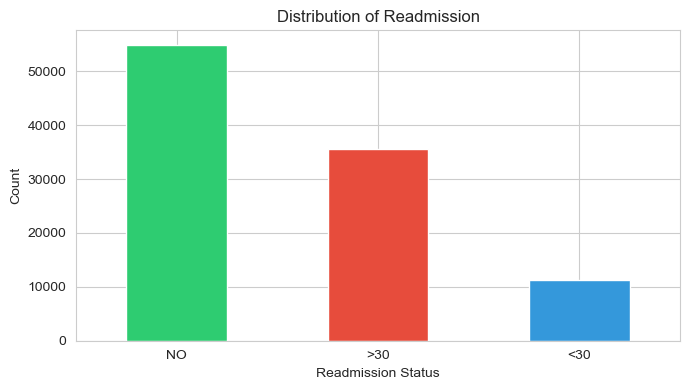

In [6]:
# Target variable distribution
print("Target Variable - 'readmitted':")
print(df['readmitted'].value_counts())
print()
print(df['readmitted'].value_counts(normalize=True).round(3) * 100, "%")

plt.figure(figsize=(7, 4))
df['readmitted'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c', '#3498db'])
plt.title('Distribution of Readmission')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Target Variable Engineering
We convert the multi-class target to **binary** (readmitted within 30 days = 1, else = 0)

Binary Target Distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64



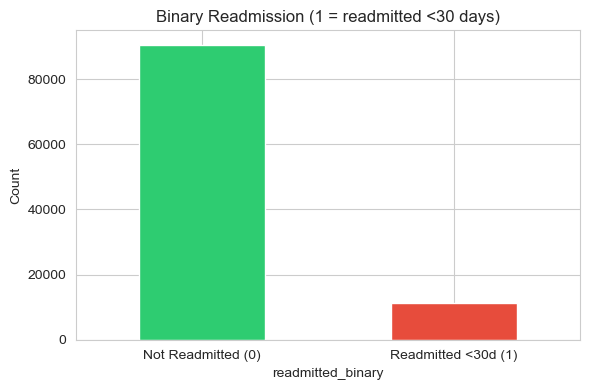

In [7]:
# Convert target to binary classification
# '<30' = readmitted within 30 days -> 1 (positive class)
# '>30' or 'NO' -> 0 (negative class)

df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("Binary Target Distribution:")
print(df['readmitted_binary'].value_counts())
print()

plt.figure(figsize=(6, 4))
df['readmitted_binary'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Binary Readmission (1 = readmitted <30 days)')
plt.xticks([0, 1], ['Not Readmitted (0)', 'Readmitted <30d (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Missing Value Treatment

In [8]:
# Replace '?' with NaN (dataset uses '?' for missing)
df.replace('?', np.nan, inplace=True)

# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with Missing Values:")
print(missing_df)

Columns with Missing Values:
                   Missing Count  Missing %
weight                     98569  96.858479
max_glu_serum              96420  94.746772
A1Cresult                  84748  83.277322
medical_specialty          49949  49.082208
payer_code                 40256  39.557416
race                        2273   2.233555
diag_3                      1423   1.398306
diag_2                       358   0.351787
diag_1                        21   0.020636


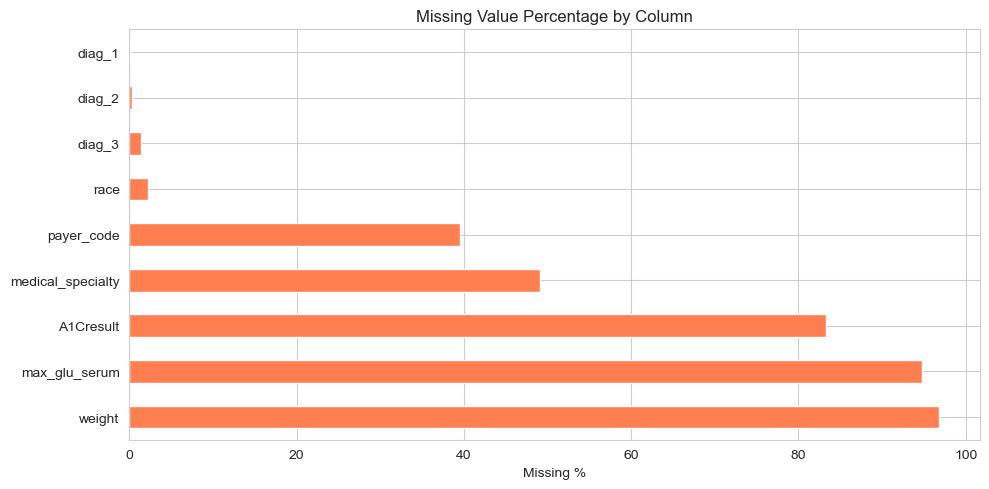

In [9]:
# Visualize missing values
plt.figure(figsize=(10, 5))
missing_df['Missing %'].plot(kind='barh', color='coral')
plt.title('Missing Value Percentage by Column')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

In [10]:
# Drop columns with >40% missing values
threshold = 40
cols_to_drop = missing_df[missing_df['Missing %'] > threshold].index.tolist()
print(f"Dropping columns with >{threshold}% missing: {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

# Drop 'weight' column separately (very high missing ~97%)
if 'weight' in df.columns:
    df.drop(columns=['weight'], inplace=True)
    print("Dropped: weight")

Dropping columns with >40% missing: ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']


In [11]:
# Remove records for patients who died or were transferred to hospice
# (They won't be readmitted, so these records are not useful)
if 'discharge_disposition_id' in df.columns:
    expired_ids = [11, 13, 14, 19, 20, 21]  # Expired / Hospice
    df = df[~df['discharge_disposition_id'].isin(expired_ids)]
    print(f"Shape after removing expired/hospice: {df.shape}")

Shape after removing expired/hospice: (99343, 47)


In [12]:
# For remaining missing values - impute with mode (categorical) or median (numerical)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


## 4. Exploratory Data Analysis (EDA)

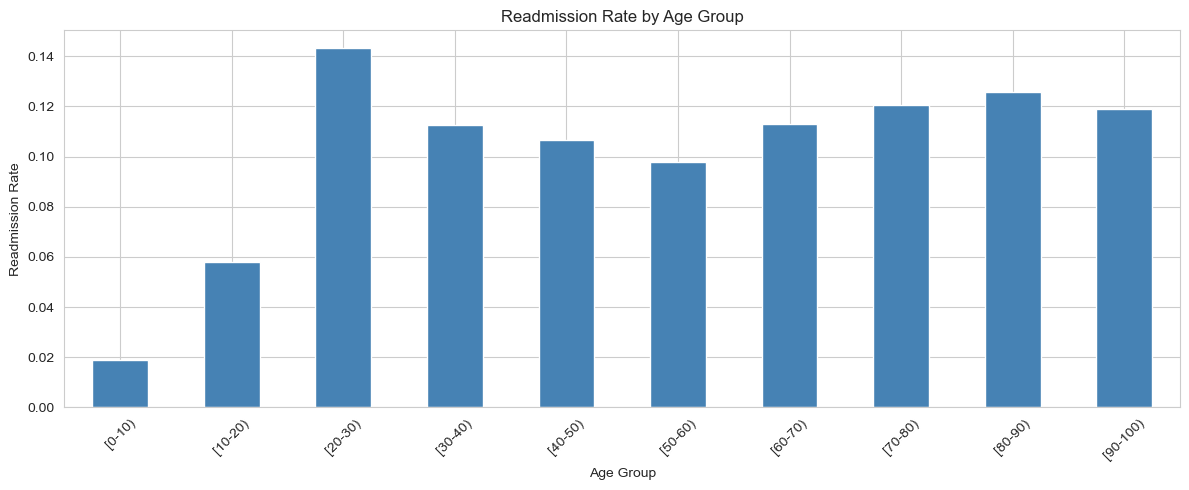

In [13]:
# Age distribution vs Readmission
plt.figure(figsize=(12, 5))
age_readmit = df.groupby('age')['readmitted_binary'].mean().sort_index()
age_readmit.plot(kind='bar', color='steelblue')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

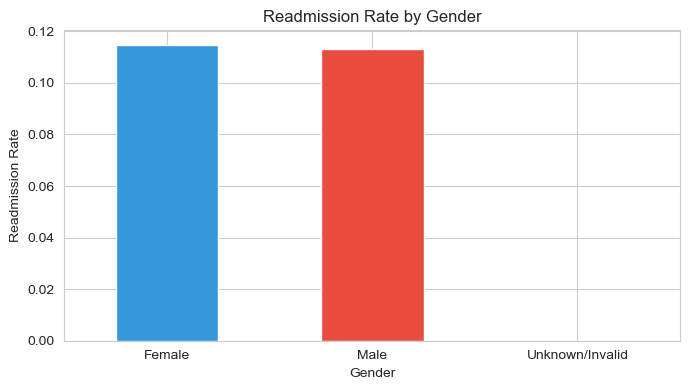

In [14]:
# Gender vs Readmission
plt.figure(figsize=(7, 4))
df.groupby('gender')['readmitted_binary'].mean().plot(kind='bar', color=['#3498db', '#e74c3c', '#95a5a6'])
plt.title('Readmission Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

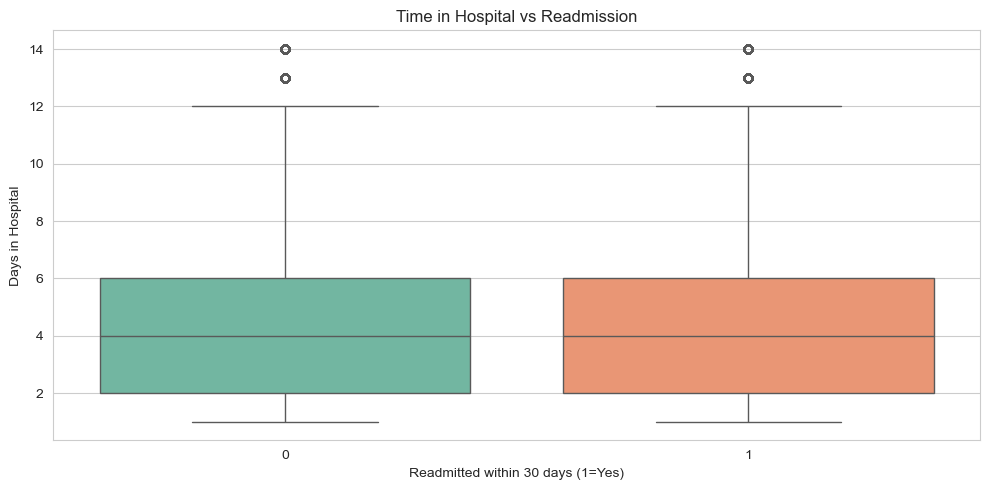

In [15]:
# Length of Stay vs Readmission
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='readmitted_binary', y='time_in_hospital', palette='Set2')
plt.title('Time in Hospital vs Readmission')
plt.xlabel('Readmitted within 30 days (1=Yes)')
plt.ylabel('Days in Hospital')
plt.tight_layout()
plt.show()

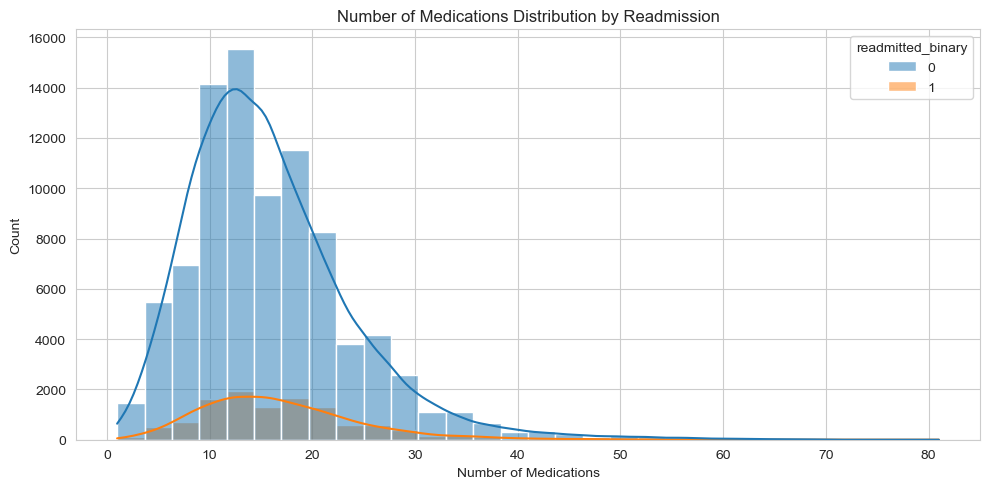

In [16]:
# Number of medications vs Readmission
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='num_medications', hue='readmitted_binary', kde=True, bins=30)
plt.title('Number of Medications Distribution by Readmission')
plt.xlabel('Number of Medications')
plt.tight_layout()
plt.show()

In [17]:
# HbA1c test result vs Readmission
if 'A1Cresult' in df.columns:
    plt.figure(figsize=(8, 4))
    df.groupby('A1Cresult')['readmitted_binary'].mean().plot(kind='bar', color='darkorange')
    plt.title('Readmission Rate by HbA1c (A1C) Result')
    plt.xlabel('A1C Result')
    plt.ylabel('Readmission Rate')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

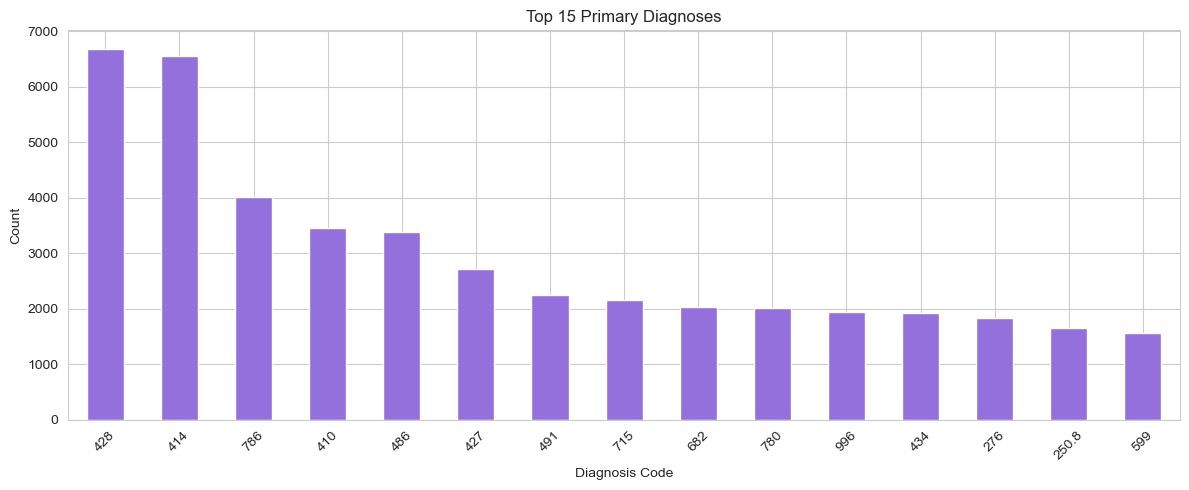

In [18]:
# Primary Diagnosis distribution (top 15)
if 'diag_1' in df.columns:
    plt.figure(figsize=(12, 5))
    df['diag_1'].value_counts().head(15).plot(kind='bar', color='mediumpurple')
    plt.title('Top 15 Primary Diagnoses')
    plt.xlabel('Diagnosis Code')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

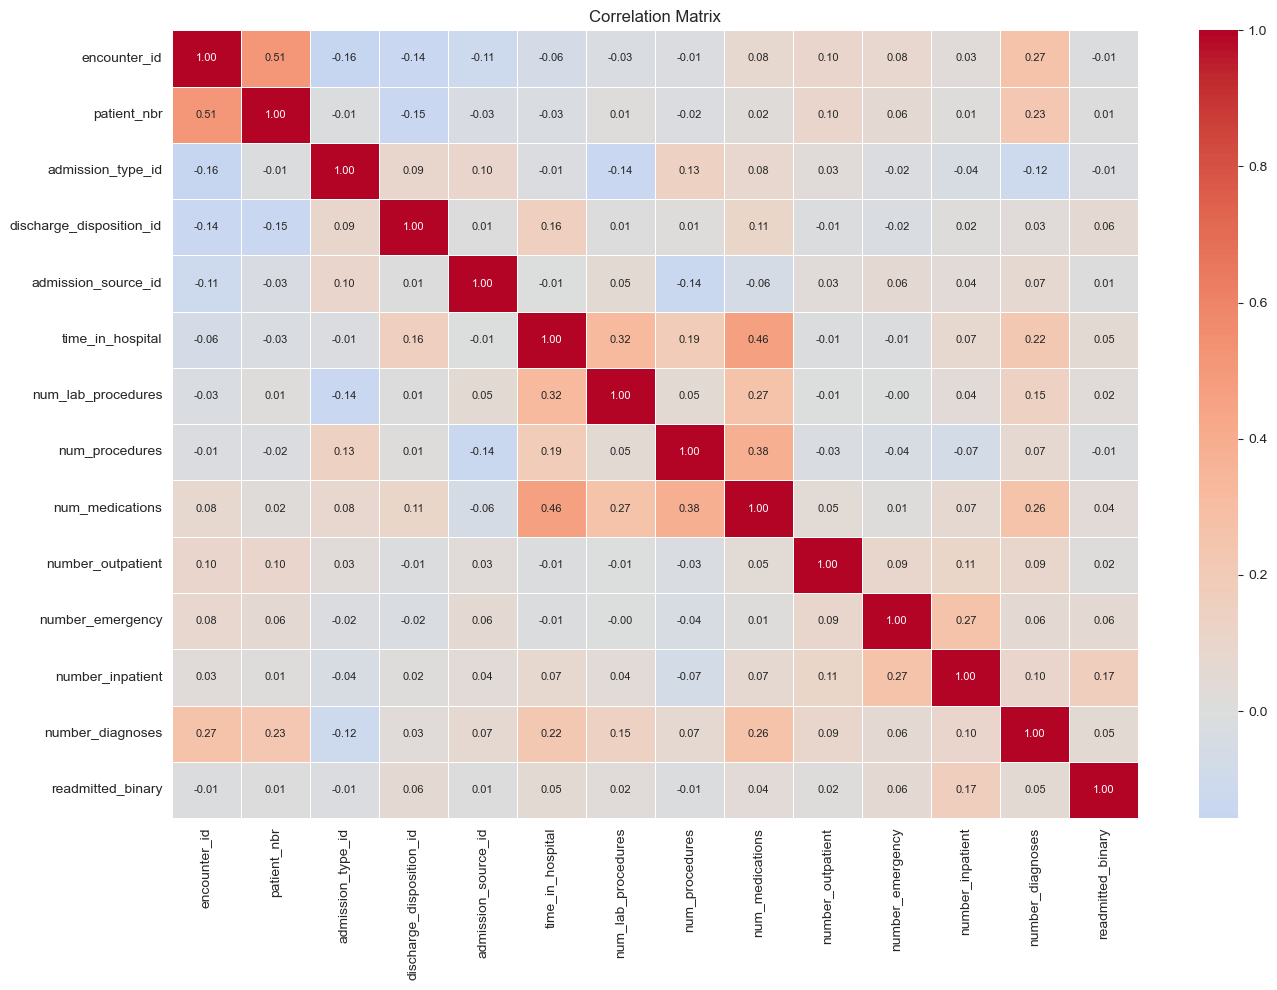

In [19]:
# Correlation heatmap (numeric columns)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Medicine Analysis: Which Medicines Are Most Effective?

In [20]:
# Medicine columns in the dataset
medicine_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Keep only columns that exist in the dataframe
medicine_cols = [col for col in medicine_cols if col in df.columns]
print(f"Medicine columns found: {len(medicine_cols)}")
print(medicine_cols)

Medicine columns found: 23
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


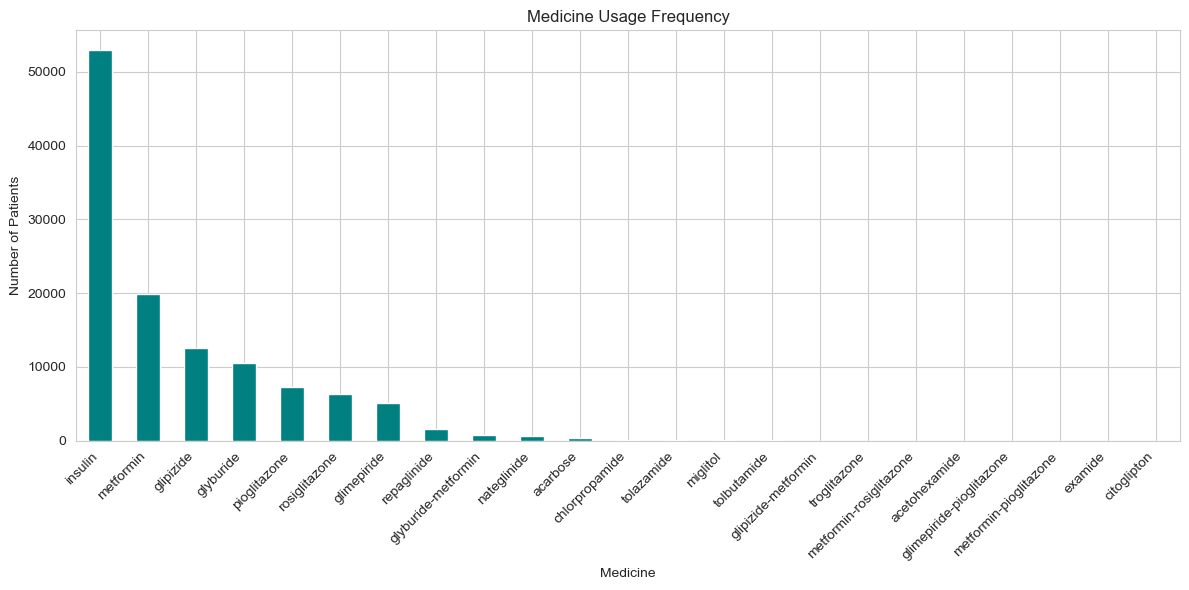

In [21]:
# Medicine usage frequency (patients receiving that drug)
med_usage = {}
for med in medicine_cols:
    med_usage[med] = (df[med] != 'No').sum()

med_usage_df = pd.Series(med_usage).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
med_usage_df.plot(kind='bar', color='teal')
plt.title('Medicine Usage Frequency')
plt.xlabel('Medicine')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Readmission rate by medicine dosage change
# Patients whose medicine was changed (Up/Down) vs steady/no

med_readmit = {}
for med in medicine_cols:
    changed = df[df[med].isin(['Up', 'Down'])]['readmitted_binary'].mean()
    steady = df[df[med] == 'Steady']['readmitted_binary'].mean()
    no_med = df[df[med] == 'No']['readmitted_binary'].mean()
    med_readmit[med] = {'Changed': changed, 'Steady': steady, 'No': no_med}

med_readmit_df = pd.DataFrame(med_readmit).T.dropna(how='all')
print("Readmission rate by medication change status:")
med_readmit_df.sort_values('Changed', ascending=False).head(10)

Readmission rate by medication change status:


,Changed,Steady,No
miglitol,0.285714,0.064516,0.113892
acarbose,0.230769,0.085616,0.113956
repaglinide,0.153333,0.133041,0.113560
glipizide,0.140244,0.112488,0.113671
insulin,0.137934,0.113738,0.102115
pioglitazone,0.135447,0.104951,0.114477
glimepiride,0.120858,0.101540,0.114454
glyburide,0.100661,0.108164,0.114681
metformin,0.095907,0.097820,0.117939
rosiglitazone,0.093750,0.105820,0.114468


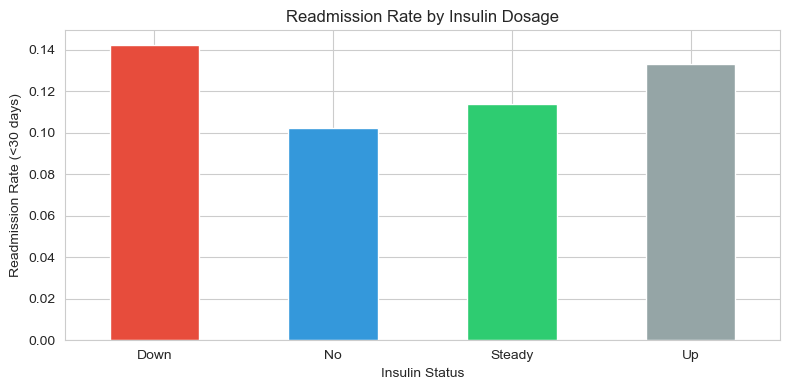

In [23]:
# Insulin: most commonly prescribed — detailed analysis
if 'insulin' in df.columns:
    plt.figure(figsize=(8, 4))
    insulin_readmit = df.groupby('insulin')['readmitted_binary'].mean()
    insulin_readmit.plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71', '#95a5a6'])
    plt.title('Readmission Rate by Insulin Dosage')
    plt.xlabel('Insulin Status')
    plt.ylabel('Readmission Rate (<30 days)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Feature Extraction & Engineering

In [24]:
# Drop columns that are not useful for prediction
cols_to_remove = ['encounter_id', 'patient_nbr', 'readmitted',
                  'examide', 'citoglipton']  # Single-value columns
cols_to_remove = [c for c in cols_to_remove if c in df.columns]
df.drop(columns=cols_to_remove, inplace=True)
print(f"Shape after dropping irrelevant columns: {df.shape}")

Shape after dropping irrelevant columns: (99343, 42)


In [25]:
# Convert age from ranges to numeric midpoints
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
if df['age'].dtype == 'object':
    df['age'] = df['age'].map(age_map)
print("Age converted to numeric midpoints.")
df['age'].describe()

Age converted to numeric midpoints.


count    99343.000000
mean        65.744290
std         15.945176
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age, dtype: float64

In [26]:
# Encode medicine columns: 'No' -> 0, any other value -> 1
for med in medicine_cols:
    if med in df.columns:
        df[med] = df[med].apply(lambda x: 0 if x == 'No' else 1)

print("Medicine columns binarized (0 = not prescribed, 1 = prescribed).")

Medicine columns binarized (0 = not prescribed, 1 = prescribed).


In [27]:
# Define the medicine columns list (added missing opening bracket and variable assignment)
medicine_cols = ['glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# Filter to only include columns that actually exist in the dataframe
medicine_cols = [col for col in medicine_cols if col in df.columns]

# Total number of medicines prescribed (only use columns that actually exist)
if medicine_cols:
    df['total_meds_prescribed'] = df[medicine_cols].sum(axis=1)
else:
    # If no medicine columns found, create a default column
    df['total_meds_prescribed'] = 0
    print("Warning: No medicine columns found in the dataframe")

# Service utilization: total number of visits
visit_cols = [c for c in ['number_outpatient', 'number_emergency', 'number_inpatient'] if c in df.columns]
if visit_cols:
    df['total_visits'] = df[visit_cols].sum(axis=1)

# Diagnosis groups based on ICD-9 codes
def map_diag(diag):
    try:
        diag = str(diag)  # Convert to string first
        if diag.startswith('V') or diag.startswith('E'):
            return 'Other'
        val = float(diag)
        if 390 <= val <= 459 or val == 785: return 'Circulatory'
        elif 460 <= val <= 519 or val == 786: return 'Respiratory'
        elif 520 <= val <= 579 or val == 787: return 'Digestive'
        elif 250 <= val <= 250.99: return 'Diabetes'
        elif 800 <= val <= 999: return 'Injury'
        elif 710 <= val <= 739: return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788: return 'Genitourinary'
        elif 140 <= val <= 239: return 'Neoplasms'
        else: return 'Other'
    except:
        return 'Other'

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    if diag_col in df.columns:
        df[f'{diag_col}_group'] = df[diag_col].apply(map_diag)

print("New features created: total_meds_prescribed, total_visits, diagnosis groups")
# Only describe columns that exist
existing_cols = [col for col in ['total_meds_prescribed', 'total_visits'] if col in df.columns]
if existing_cols:
    print(df[existing_cols].describe())  # Added print() to display the output

New features created: total_meds_prescribed, total_visits, diagnosis groups
       total_meds_prescribed  total_visits
count           99343.000000  99343.000000
mean                0.964547      1.198625
std                 0.769197      2.294215
min                 0.000000      0.000000
25%                 0.000000      0.000000
50%                 1.000000      0.000000
75%                 1.000000      2.000000
max                 5.000000     80.000000


In [28]:
# Drop raw diagnosis code columns (use group columns instead)
for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    if diag_col in df.columns:
        df.drop(columns=[diag_col], inplace=True)

# Label Encoding for binary/ordinal categorical columns
le = LabelEncoder()
binary_cats = ['gender', 'change', 'diabetesMed']
for col in binary_cats:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# One-Hot Encoding for nominal categorical columns
nominal_cats = ['race', 'A1Cresult', 'max_glu_serum',
                'diag_1_group', 'diag_2_group', 'diag_3_group']
nominal_cats = [c for c in nominal_cats if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cats, drop_first=True)

print(f"Shape after encoding: {df.shape}")
df.head(2)

Shape after encoding: (99343, 68)


,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,total_meds_prescribed,total_visits,race_Asian,race_Caucasian,race_Hispanic,race_Other,diag_1_group_Diabetes,diag_1_group_Digestive,diag_1_group_Genitourinary,diag_1_group_Injury,diag_1_group_Musculoskeletal,diag_1_group_Neoplasms,diag_1_group_Other,diag_1_group_Respiratory,diag_2_group_Diabetes,diag_2_group_Digestive,diag_2_group_Genitourinary,diag_2_group_Injury,diag_2_group_Musculoskeletal,diag_2_group_Neoplasms,diag_2_group_Other,diag_2_group_Respiratory,diag_3_group_Diabetes,diag_3_group_Digestive,diag_3_group_Genitourinary,diag_3_group_Injury,diag_3_group_Musculoskeletal,diag_3_group_Neoplasms,diag_3_group_Other,diag_3_group_Respiratory
0,0,5,6,25,1,1,MC,41,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False
1,0,15,1,1,7,3,MC,59,0,18,0,0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [29]:
# Prepare features (X) and target (y)
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Ensure all remaining columns are numeric
X = X.select_dtypes(include=[np.number])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution: {y.value_counts().to_dict()}")

X shape: (99343, 38)
y shape: (99343,)

Class distribution: {0: 88029, 1: 11314}


## 7. Feature Selection

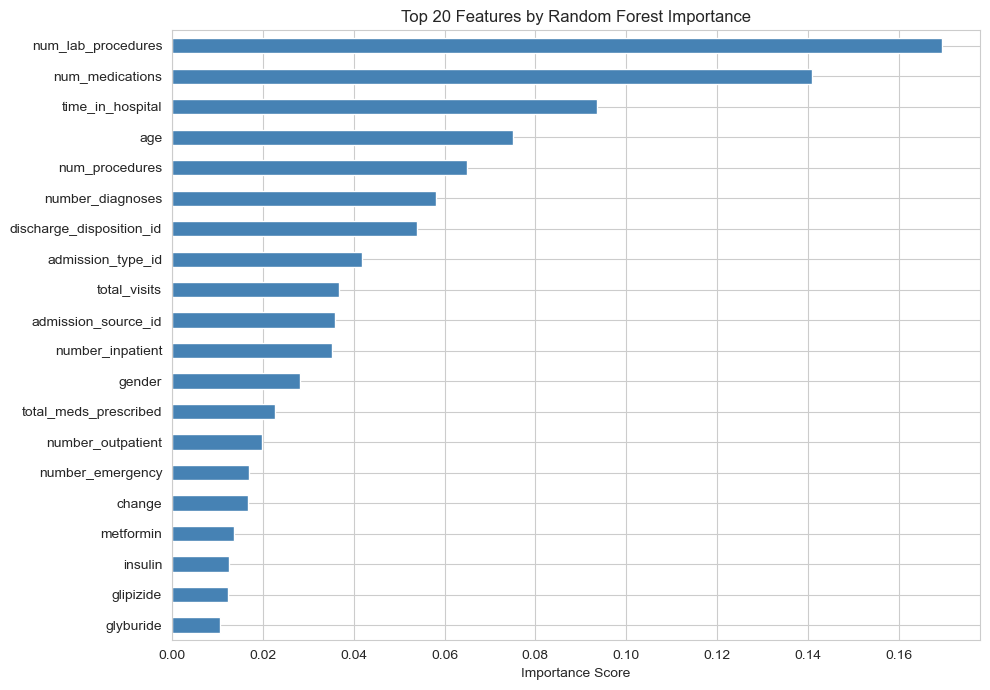

Top 20 Features:
num_lab_procedures          0.169383
num_medications             0.140937
time_in_hospital            0.093553
age                         0.074986
num_procedures              0.065027
number_diagnoses            0.058218
discharge_disposition_id    0.053975
admission_type_id           0.041798
total_visits                0.036776
admission_source_id         0.035971
number_inpatient            0.035209
gender                      0.028274
total_meds_prescribed       0.022596
number_outpatient           0.019730
number_emergency            0.016880
change                      0.016821
metformin                   0.013752
insulin                     0.012650
glipizide                   0.012292
glyburide                   0.010613
dtype: float64


In [30]:
# Method 1: Random Forest Feature Importance
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

feat_importance = pd.Series(rf_selector.feature_importances_, index=X.columns)
top_features = feat_importance.nlargest(20)

plt.figure(figsize=(10, 7))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Features by Random Forest Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 20 Features:")
print(top_features)

In [31]:
# Select top N features for modeling
top_n = 25
selected_features = feat_importance.nlargest(top_n).index.tolist()
print(f"Selected top {top_n} features: {selected_features}")

X_selected = X[selected_features]
print(f"X_selected shape: {X_selected.shape}")

Selected top 25 features: ['num_lab_procedures', 'num_medications', 'time_in_hospital', 'age', 'num_procedures', 'number_diagnoses', 'discharge_disposition_id', 'admission_type_id', 'total_visits', 'admission_source_id', 'number_inpatient', 'gender', 'total_meds_prescribed', 'number_outpatient', 'number_emergency', 'change', 'metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'glimepiride', 'diabetesMed', 'repaglinide']
X_selected shape: (99343, 25)


## 8. Train-Test Split & Class Imbalance Treatment (SMOTE)

In [32]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())

Training set: (79474, 25)
Test set: (19869, 25)

Class distribution in training:
readmitted_binary
0    70423
1     9051
Name: count, dtype: int64


In [33]:
# Apply SMOTE to handle class imbalance
print("Before SMOTE:")
print(f"  Class 0: {(y_train == 0).sum()} | Class 1: {(y_train == 1).sum()}")
print(f"  Imbalance ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Class 0: {(y_train_resampled == 0).sum()} | Class 1: {(y_train_resampled == 1).sum()}")
print(f"  X_train_resampled shape: {X_train_resampled.shape}")

Before SMOTE:
  Class 0: 70423 | Class 1: 9051
  Imbalance ratio: 7.78:1

After SMOTE:
  Class 0: 70423 | Class 1: 70423
  X_train_resampled shape: (140846, 25)


In [34]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


## 9. Model Building — Baseline Models

In [35]:
# Helper function for model evaluation
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    if roc: print(f"ROC-AUC   : {roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'ROC-AUC': roc}


Model: Logistic Regression
Accuracy  : 0.7458
Precision : 0.1372
Recall    : 0.2329
F1-Score  : 0.1726
ROC-AUC   : 0.5369

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85     17606
           1       0.14      0.23      0.17      2263

    accuracy                           0.75     19869
   macro avg       0.51      0.52      0.51     19869
weighted avg       0.81      0.75      0.77     19869



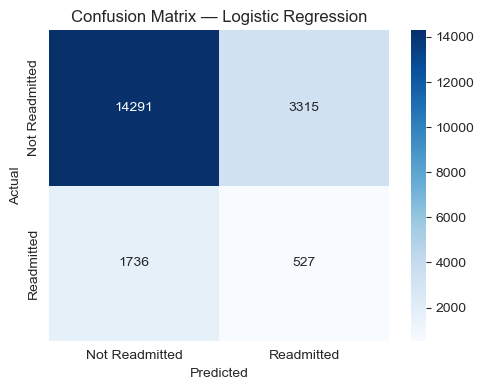

In [36]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
results_lr = evaluate_model(lr, X_train_scaled, y_train_resampled,
                            X_test_scaled, y_test, 'Logistic Regression')


Model: Decision Tree
Accuracy  : 0.7324
Precision : 0.1378
Recall    : 0.2567
F1-Score  : 0.1794
ROC-AUC   : 0.5452

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84     17606
           1       0.14      0.26      0.18      2263

    accuracy                           0.73     19869
   macro avg       0.52      0.53      0.51     19869
weighted avg       0.81      0.73      0.76     19869



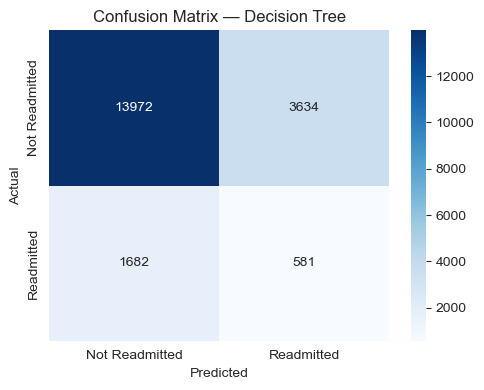

In [37]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
results_dt = evaluate_model(dt, X_train_resampled, y_train_resampled,
                            X_test, y_test, 'Decision Tree')


Model: Random Forest
Accuracy  : 0.8249
Precision : 0.1645
Recall    : 0.1317
F1-Score  : 0.1463
ROC-AUC   : 0.5864

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     17606
           1       0.16      0.13      0.15      2263

    accuracy                           0.82     19869
   macro avg       0.53      0.52      0.52     19869
weighted avg       0.81      0.82      0.82     19869



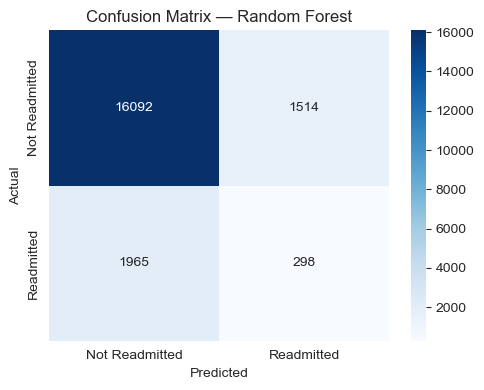

In [38]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf = evaluate_model(rf, X_train_resampled, y_train_resampled,
                            X_test, y_test, 'Random Forest')


Model: XGBoost
Accuracy  : 0.7883
Precision : 0.1575
Recall    : 0.1975
F1-Score  : 0.1753
ROC-AUC   : 0.5748

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88     17606
           1       0.16      0.20      0.18      2263

    accuracy                           0.79     19869
   macro avg       0.53      0.53      0.53     19869
weighted avg       0.81      0.79      0.80     19869



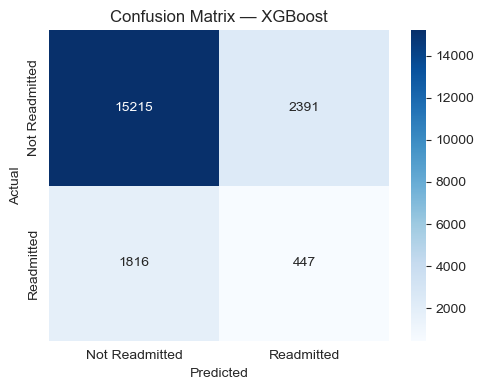

In [39]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
results_xgb = evaluate_model(xgb, X_train_resampled, y_train_resampled,
                             X_test, y_test, 'XGBoost')


Model: Gradient Boosting
Accuracy  : 0.7320
Precision : 0.1411
Recall    : 0.2660
F1-Score  : 0.1844
ROC-AUC   : 0.5545

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84     17606
           1       0.14      0.27      0.18      2263

    accuracy                           0.73     19869
   macro avg       0.52      0.53      0.51     19869
weighted avg       0.81      0.73      0.77     19869



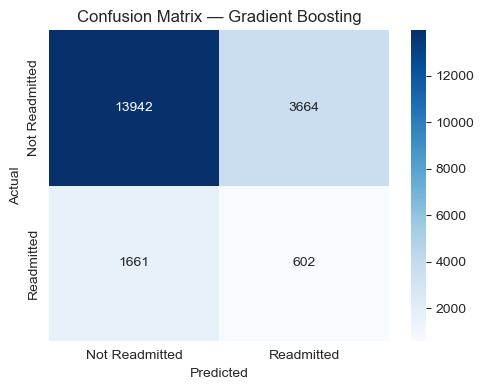

In [40]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
results_gb = evaluate_model(gb, X_train_resampled, y_train_resampled,
                            X_test, y_test, 'Gradient Boosting')

## 10. Model Comparison

In [41]:
# Compare all models
results_all = pd.DataFrame([results_lr, results_dt, results_rf, results_xgb, results_gb])
results_all = results_all.set_index('Model').round(4)
print("Model Comparison:")
results_all

Model Comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7458,0.1372,0.2329,0.1726,0.5369
Decision Tree,0.7324,0.1378,0.2567,0.1794,0.5452
Random Forest,0.8249,0.1645,0.1317,0.1463,0.5864
XGBoost,0.7883,0.1575,0.1975,0.1753,0.5748
Gradient Boosting,0.7320,0.1411,0.2660,0.1844,0.5545


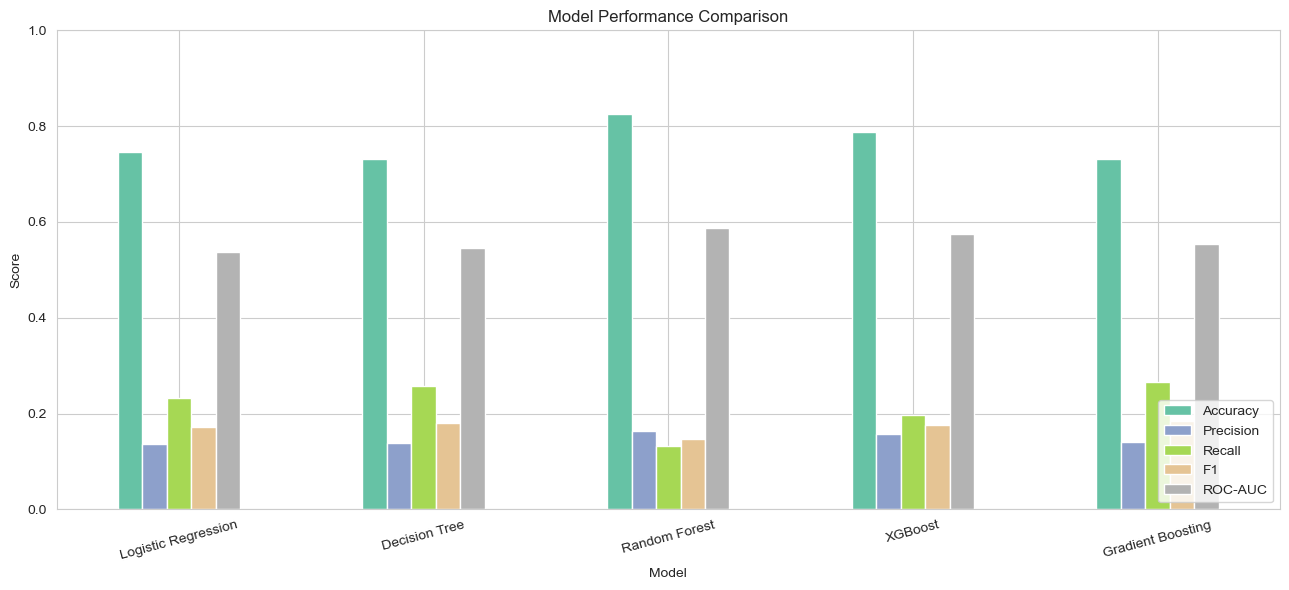

In [42]:
# Visual comparison
results_all[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 6), colormap='Set2'
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()